# TD 01 — Analyse en Composantes Principales (ACP) et Analyse Catégorielle
## Jeu de données : Lung Cancer Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
data = pd.read_csv('lung_cancer_dataset.csv')
print(data.head())

  Patient_ID  Diagnosis_Year Diagnosis_Date       WHO_Region    Country  Age  \
0    LC-0001            2020     2020-11-04  Western Pacific      China   46   
1    LC-0002            2021     2021-12-09         Americas     Mexico   71   
2    LC-0003            2017     2017-04-05  Western Pacific      Japan   53   
3    LC-0004            2018     2018-11-24  Western Pacific  Singapore   55   
4    LC-0005            2024     2024-02-19  Western Pacific   Malaysia   54   

  Age_Group  Gender  Smoking_Status  Cigarettes_Per_Day  ...  Symptom_Count  \
0     40-49  Female  Current Smoker                  28  ...              5   
1     70-79    Male   Former Smoker                   5  ...              5   
2     50-59  Female    Never Smoked                   0  ...              3   
3     50-59    Male  Current Smoker                  21  ...              6   
4     50-59    Male    Never Smoked                   0  ...              5   

   Cancer_Type   NSCLC_Subtype Cancer_Stage 

## Nettoyage du jeu de données avant l'analyse.

In [10]:
data = data.drop_duplicates().replace([np.inf, -np.inf], np.nan)

## Recuperation des data quantitative

In [11]:
quantitative_data = data.select_dtypes(include='number').copy()
quantitative_data = quantitative_data.dropna(axis=1, how='all')
quantitative_data = quantitative_data.fillna(quantitative_data.median())

## Standardisation des variables quantitatives.

In [12]:
x_scaled = StandardScaler().fit_transform(quantitative_data)

## Projection des individus sur les composantes

In [13]:
pca = PCA()
pca_res = pca.fit_transform(x_scaled)

## Tableau récapitulatif des valeurs propres et de leur contribution.

In [14]:
eig = pd.DataFrame({
	'Dimension': [f'Dim{x + 1}' for x in range(10)],
	'Valeur propre': pca.explained_variance_,
	'% valeur propre': np.round(pca.explained_variance_ratio_ * 100, 2),
	'% cum. val. propre': np.round(
		np.cumsum(pca.explained_variance_ratio_) * 100, 2
	)
})
print(eig)

  Dimension  Valeur propre  % valeur propre  % cum. val. propre
0      Dim1       3.257592            32.56               32.56
1      Dim2       1.518044            15.17               47.73
2      Dim3       1.040895            10.40               58.14
3      Dim4       1.018477            10.18               68.32
4      Dim5       0.972155             9.72               78.03
5      Dim6       0.965591             9.65               87.68
6      Dim7       0.669497             6.69               94.38
7      Dim8       0.308798             3.09               97.46
8      Dim9       0.185176             1.85               99.31
9     Dim10       0.068777             0.69              100.00


## Diagramme en bâtons des pourcentages de variance expliquée.

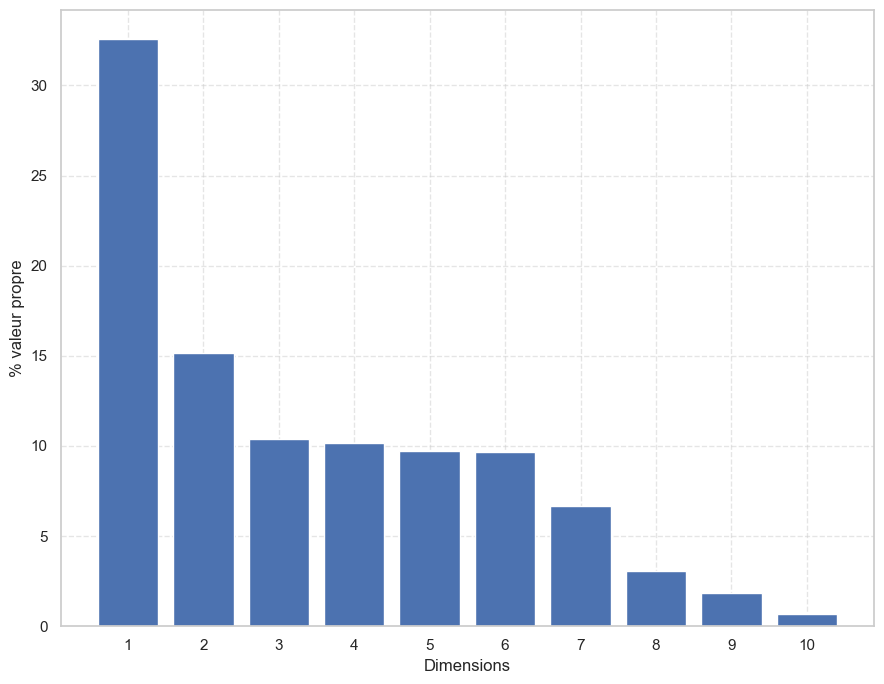

In [15]:
dimensions = range(1, len(pca.explained_variance_ratio_) + 1)

plt.figure(figsize=(9, 7))
plt.bar(dimensions, pca.explained_variance_ratio_ * 100)
plt.xlabel('Dimensions')
plt.ylabel('% valeur propre')
plt.xticks(list(dimensions))

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Graphique des variables

Attention : pour des facilités d'affichage, les données sont centrées-réduites


/Users/timeo/Desktop/IUT3/Technique ia/TD1/TD1_BOURBON_DOOM/biplot.py:61: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x="x_c",y="y_c",data=data[cat==i], color=color_temp,
/Users/timeo/Desktop/IUT3/Technique ia/TD1/TD1_BOURBON_DOOM/biplot.py:61: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x="x_c",y="y_c",data=data[cat==i], color=color_temp,
/Users/timeo/Desktop/IUT3/Technique ia/TD1/TD1_BOURBON_DOOM/biplot.py:61: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x="x_c",y="y_c",data=data[cat==i], color=color_temp,
/Users/timeo/Desktop/IUT3/Technique ia/TD1/TD1_BOURBON_DOOM/biplot.py:61: FutureWarning: 

`shade` is now dep

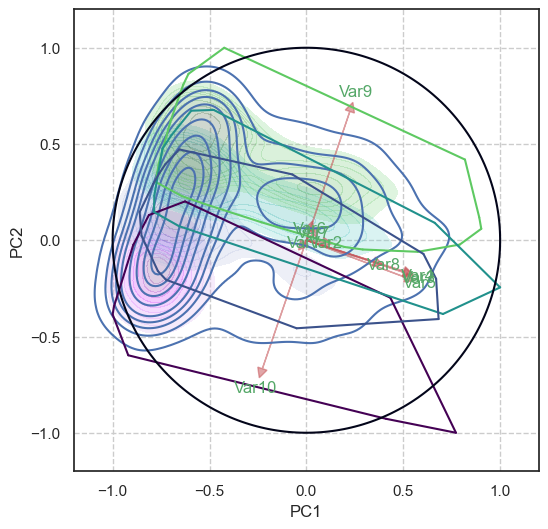

In [ ]:
from biplot import biplot

stage_codes = data["Cancer_Stage"].astype("category").cat.codes.to_numpy()

biplot(
    score=pca_res[:, 0:2],
    coeff=pca.components_[0:2, :].T,
    cat=stage_cods,
    density=True
)

plt.show()
plt.show()

# Graphique des individus de l'ACP

### Premier plan factoriel

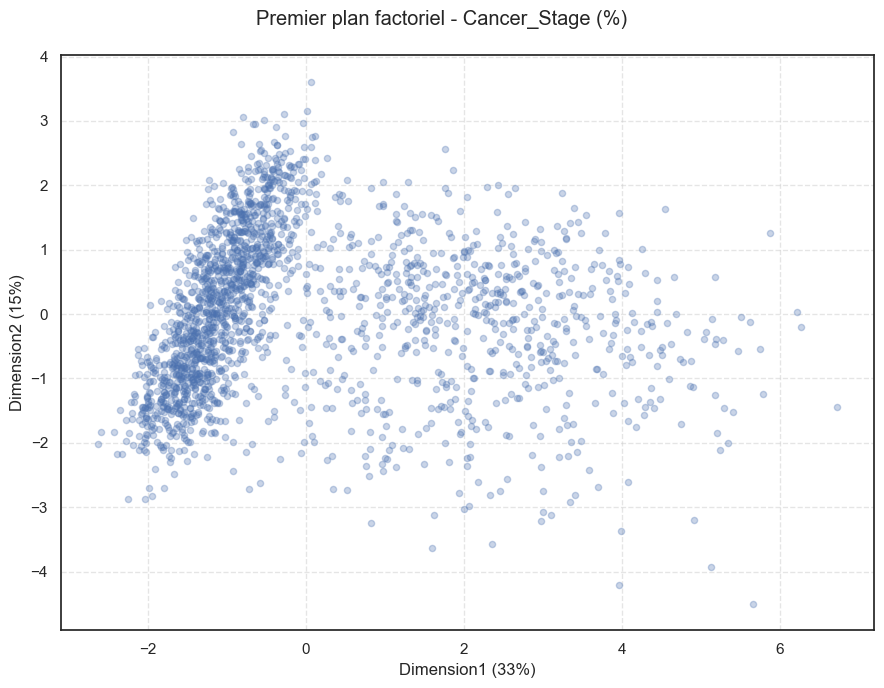

In [21]:
pcadf = pd.DataFrame({
    "Dim1": pca_res[:, 0],
    "Dim2": pca_res[:, 1],
    "Cancer_Stage": data["Cancer_Stage"]  # Cancer_Stage n'influencera pas le contenu du graphique car elle n'est pas prise en compte dans plot.scatter()
})

fig, ax = plt.subplots(figsize=(9, 7))

pcadf.plot.scatter("Dim1", "Dim2", alpha=0.3, ax=ax)

ax.set_xlabel(f"Dimension1 ({eig.loc[0, '% valeur propre']:.0f}%)")
ax.set_ylabel(f"Dimension2 ({eig.loc[1, '% valeur propre']:.0f}%)")
plt.suptitle("Premier plan factoriel - Cancer_Stage (%)")

ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Deuxième plan factoriel

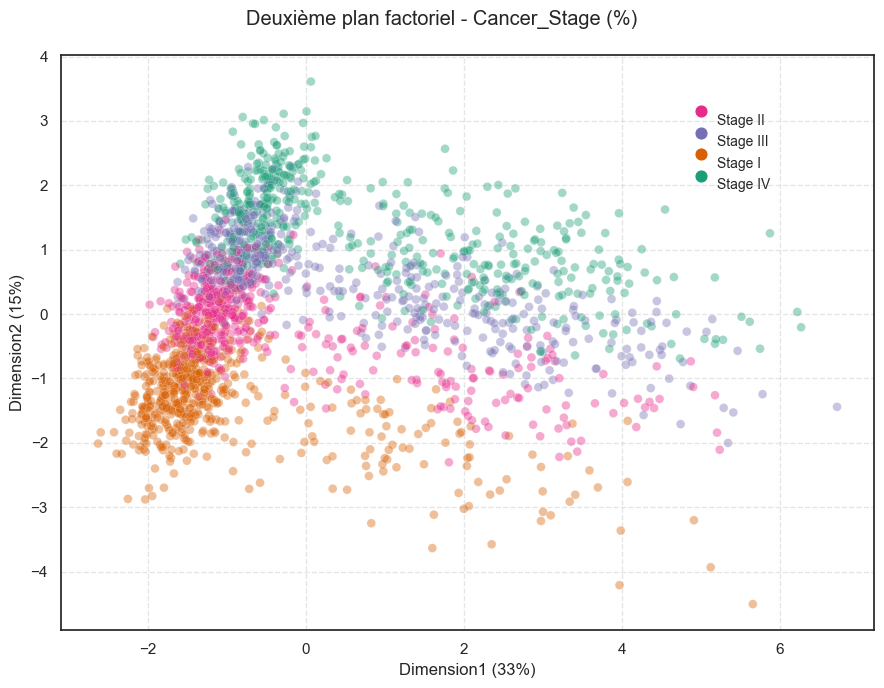

In [22]:
plt.figure(figsize=(9, 7))

palette = plt.get_cmap("Dark2")
couleurs = dict(zip(data["Cancer_Stage"].drop_duplicates(), palette(range(10))))
position = dict(zip(couleurs.keys(), range(10)))

pcadf.plot.scatter("Dim1", "Dim2", c=[couleurs[p] for p in data["Cancer_Stage"]], alpha=0.4, s=40, edgecolor="white", linewidth=0.3, ax=plt.gca())

for cont, coul in couleurs.items():
    plt.scatter(5, position[cont] / 3 + 2.15, c=[coul], s=60)
    plt.text(5.2, position[cont] / 3 + 2, cont, fontsize=10, va="center")
    plt.xlabel(f"Dimension1 ({eig.loc[0, '% valeur propre']:.0f}%)")
    plt.ylabel(f"Dimension2 ({eig.loc[1, '% valeur propre']:.0f}%)")
    plt.suptitle("Deuxième plan factoriel - Cancer_Stage (%)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
